In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from typing import List, Tuple

In [2]:
# ========================= 全局配置常量 =========================
DATA_ROOT = r"C:\Users\17934\Desktop\Artificial-Intelligence\3-Resources\Codes\DataSet\Figure\banana-detection"
IMAGE_RAW_SIZE = 256
CSV_REQUIRED_COLUMNS = ["img_name", "label", "xmin", "ymin", "xmax", "ymax"]
# ==============================================================

class BananasDataset(Dataset):
    """
    香蕉目标检测数据集
    初始化仅加载标签元数据，图像在索引访问时实时读取，内存占用与数据集大小无关
    标签格式：[cls, x1, y1, x2, y2]，坐标归一化至 [0, 1]
    单样本标签输出 shape: [1, 5]
    """

    def __init__(self, is_train: bool = True):
        super().__init__()
        self.is_train = is_train
        sub_dir = "bananas_train" if is_train else "bananas_val"

        # 路径拼接（适配本地目录结构）
        self._base_dir = os.path.join(DATA_ROOT, sub_dir)
        self._csv_path = os.path.join(self._base_dir, "label.csv")
        self._img_dir = os.path.join(self._base_dir, "images")

        # 前置路径与格式校验
        if not os.path.exists(self._csv_path):
            raise FileNotFoundError(f"标签文件不存在：{self._csv_path}")
        if not os.path.isdir(self._img_dir):
            raise FileNotFoundError(f"图像目录不存在：{self._img_dir}")

        df = pd.read_csv(self._csv_path)
        missing_cols = [col for col in CSV_REQUIRED_COLUMNS if col not in df.columns]
        if missing_cols:
            raise ValueError(f"标签CSV缺少必要字段：{missing_cols}")

        # 仅保存文件名与标签张量，不加载任何图像数据
        self.img_names: List[str] = df["img_name"].tolist()
        raw_targets = df[["label", "xmin", "ymin", "xmax", "ymax"]].values.astype("float32")
        raw_targets[:, 1:] /= IMAGE_RAW_SIZE
        self.targets = torch.from_numpy(raw_targets).unsqueeze(1)

        mode = "training" if is_train else "validation"
        print(f"Loaded {len(self.img_names)} {mode} examples")

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        img_path = os.path.join(self._img_dir, self.img_names[idx])
        # 实时读取图像，输出 [C, H, W] float32 RGB
        img = torchvision.io.read_image(img_path).float()
        label = self.targets[idx]
        return img, label

    def __len__(self) -> int:
        return len(self.img_names)


def load_data_bananas(
    batch_size: int,
    num_workers: int = 0,
    pin_memory: bool = None
) -> Tuple[DataLoader, DataLoader]:
    """
    构造训练/验证数据加载器
    :param batch_size: 批次大小
    :param num_workers: 加载进程数
    :param pin_memory: 锁页内存，默认自动适配CUDA环境
    """
    
    if pin_memory is None:
        pin_memory = torch.cuda.is_available()

    train_iter = DataLoader(
        BananasDataset(is_train=True),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False
    )
    val_iter = DataLoader(
        BananasDataset(is_train=False),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        drop_last=False
    )
    return train_iter, val_iter

In [3]:
if __name__ == "__main__":
    batch_size = 32
    train_iter, val_iter = load_data_bananas(batch_size=batch_size)
    batch = next(iter(train_iter))
    print("图像Tensor shape:", batch[0].shape)
    print("标签Tensor shape:", batch[1].shape)


Loaded 1000 training examples
Loaded 100 validation examples
图像Tensor shape: torch.Size([32, 3, 256, 256])
标签Tensor shape: torch.Size([32, 1, 5])


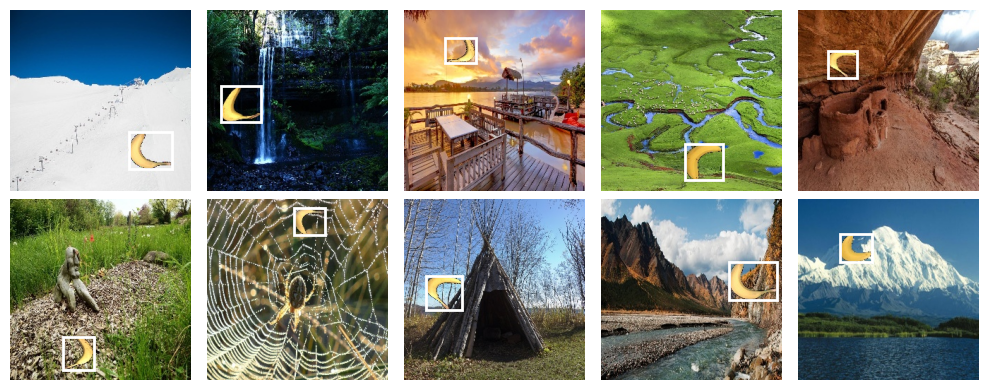

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_detection_batch(batch, edge_size=256, num_show=10):
    """
    目标检测批量可视化
    batch: (imgs, labels)
        imgs: [B,C,H,W] float 0~255
        labels: [B,1,5] [cls, x1,y1,x2,y2] 归一化坐标
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle

    imgs, labels = batch
    imgs = imgs[:num_show].permute(0, 2, 3, 1) / 255
    labels = labels[:num_show]

    rows = 2
    cols = num_show // rows
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()

    for ax, img_tensor, label in zip(axes, imgs, labels):
        ax.imshow(img_tensor.cpu().numpy())
        ax.axis("off")
        bbox = label[0][1:5] * edge_size
        xmin, ymin, xmax, ymax = bbox.cpu().numpy()
        rect = Rectangle((xmin, ymin), xmax-xmin, ymax-ymin, fill=False, ec="white", lw=2)
        ax.add_patch(rect)

    plt.tight_layout()
    plt.show()

visualize_detection_batch(batch)

**SSD**

输入一张图，只进行一次网络前向传播，同时预测目标类别、物体边框

1. 基础网络层\
    图像送入 CNN 主干，提取基础视觉特征
2. **多尺度特征层**\
    在 CNN 网络后继续堆叠卷积层，生成尺寸逐级减小的特征图
    - 大尺寸特征图（视野小）：检测小物体
    - 小尺寸特征图：检测大物体
3. 检测头\
    对每一层特征图使用两个卷积滑窗\
    分别输出每个先验框属于各类别的置信度，以及每个先验框相对真实框的偏移量

**先验框**

对于一层特征图\
遍历其所有网络位置 `(i,j)`\
将 `(i,j)` 映射回原图 `(i',j')`，以该点为中心点，生成多个锚框

通常特征图的层数越深（视野越广），框的尺寸越大

如何确定每个先验框实际上属于哪个类别（用于模型的训练）：\
找到与其交并比最大的 label

In [5]:
def generate_prior_boxes(
    feat_h: int,
    feat_w: int,
    sizes: List[float],
    aspect_ratios: List[float]
) -> torch.Tensor:
    """
    为单层特征图生成默认锚框（归一化坐标，中心+宽高格式）
    Args:
        feat_h: 特征图高度
        feat_w: 特征图宽度
        sizes: 锚框尺寸占图像边长的比例列表
        aspect_ratios: 锚框长宽比列表
    Returns:
        锚框坐标 [H*W*num_anchors, 4]，格式 (cx, cy, w, h)，归一化 0~1
    """
    # 网格步长（归一化）
    step_x = 1.0 / feat_w
    step_y = 1.0 / feat_h

    # 生成网格中心点（行优先顺序，与特征图展平顺序严格对齐）
    grid_x = (torch.arange(feat_w, dtype=torch.float32) + 0.5) * step_x
    grid_y = (torch.arange(feat_h, dtype=torch.float32) + 0.5) * step_y
    cx, cy = torch.meshgrid(grid_x, grid_y, indexing='xy')
    cx, cy = cx.reshape(-1), cy.reshape(-1)

    # 计算锚框宽高：第一个尺寸搭配所有长宽比，剩余尺寸仅搭配1:1
    num_anchors = len(sizes) + len(aspect_ratios) - 1
    widths, heights = [], []
    s_base = sizes[0]
    for ratio in aspect_ratios:
        widths.append(s_base * (ratio ** 0.5))
        heights.append(s_base / (ratio ** 0.5))
    for s in sizes[1:]:
        widths.append(s)
        heights.append(s)

    widths = torch.tensor(widths, dtype=torch.float32)
    heights = torch.tensor(heights, dtype=torch.float32)

    # 广播生成所有锚框：每个中心点对应num_anchors个锚框
    num_cells = cx.shape[0]
    cx = cx.repeat_interleave(num_anchors)
    cy = cy.repeat_interleave(num_anchors)
    widths = widths.repeat(num_cells)
    heights = heights.repeat(num_cells)

    return torch.stack([cx, cy, widths, heights], dim=-1)



class DownSampleBlock(nn.Module):
    """
    高宽减半下采样模块：2组 Conv+BN+ReLU + MaxPool
    通道数切换，空间尺寸减半
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)



class ClassifyHead(nn.Module):
    """分类检测头：3x3卷积输出每个锚框的类别置信度（含背景类）"""
    def __init__(self, in_channels: int, num_anchors: int, num_classes: int):
        super().__init__()
        self.num_classes = num_classes
        self.conv = nn.Conv2d(
            in_channels,
            out_channels=num_anchors * (num_classes + 1),
            kernel_size=3,
            padding=1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)


class BBoxHead(nn.Module):
    """回归检测头：3x3卷积输出每个锚框的坐标偏移量 (dx, dy, dw, dh)"""
    def __init__(self, in_channels: int, num_anchors: int):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels=num_anchors * 4,
            kernel_size=3,
            padding=1
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)

In [6]:
class TinySSD(nn.Module):
    """
    SSD 单阶段目标检测模型
    多尺度特征图检测，每层预设锚框，端到端输出所有锚框的分类与回归预测
    """
    
    def __init__(
        self,
        num_classes: int,
        input_size: Tuple[int, int] = (256, 256),
        in_channels_list: List[int] = None,
        anchor_sizes: List[List[float]] = None,
        anchor_ratios: List[List[float]] = None
    ):
        """
        Args:
            num_classes: 目标类别数（不含背景类）
            input_size: 输入图像尺寸 (H, W)
            in_channels_list: 每层检测特征图的输入通道数
            anchor_sizes: 每层锚框尺寸（归一化比例），长度=检测层数
            anchor_ratios: 每层锚框长宽比，长度=检测层数
        """
        super().__init__()
        self.num_classes = num_classes
        self.input_size = input_size
        self.num_stages = 5  # 共5个检测尺度

        # 默认配置与原d2l版本对齐
        if in_channels_list is None:
            in_channels_list = [64, 128, 128, 128, 128]
        if anchor_sizes is None:
            anchor_sizes = [
                [0.2, 0.272], [0.37, 0.447],
                [0.54, 0.619], [0.71, 0.79],
                [0.88, 0.961]
            ]
        if anchor_ratios is None:
            anchor_ratios = [ [1, 2, 0.5] for _ in range(self.num_stages) ]

        # 参数合法性校验
        assert len(in_channels_list) == self.num_stages, "通道列表长度需等于检测层数"
        assert len(anchor_sizes) == self.num_stages, "锚框尺寸列表长度需等于检测层数"
        assert len(anchor_ratios) == self.num_stages, "锚框比例列表长度需等于检测层数"

        self.anchor_sizes = anchor_sizes
        self.anchor_ratios = anchor_ratios

        # 校验所有层锚框数量一致
        anchors_per_cell_list = [
            len(s) + len(r) - 1 for s, r in zip(anchor_sizes, anchor_ratios)
        ]
        assert len(set(anchors_per_cell_list)) == 1, "所有检测层锚框数量必须一致"
        self.num_anchors_per_cell = anchors_per_cell_list[0]

        # ========== 骨干网络 + 多尺度特征层 ==========
        self.backbone_stages = nn.ModuleList()
        # 第0层：基础网络（3次下采样，256→32）
        self.backbone_stages.append(nn.Sequential(
            DownSampleBlock(3, 16),
            DownSampleBlock(16, 32),
            DownSampleBlock(32, 64)
        ))
        # 第1-3层：下采样块
        self.backbone_stages.append(DownSampleBlock(64, 128))
        self.backbone_stages.append(DownSampleBlock(128, 128))
        self.backbone_stages.append(DownSampleBlock(128, 128))
        # 第4层：全局池化到 1x1
        self.backbone_stages.append(nn.AdaptiveMaxPool2d((1, 1)))

        # ========== 检测头 ==========
        self.cls_heads = nn.ModuleList()
        self.bbox_heads = nn.ModuleList()
        for i in range(self.num_stages):
            self.cls_heads.append(ClassifyHead(
                in_channels_list[i], self.num_anchors_per_cell, num_classes
            ))
            self.bbox_heads.append(BBoxHead(
                in_channels_list[i], self.num_anchors_per_cell
            ))

        # ========== 预生成锚框，注册为Buffer（随模型自动迁移设备） ==========
        self._register_prior_boxes()

    def _register_prior_boxes(self):
        """初始化时预计算所有层锚框，注册为模型常量Buffer
        严格对齐网络真实输出的特征图尺寸：32、16、8、4、1
        """
        all_anchors = []
        img_h, img_w = self.input_size
        
        # 第0层检测特征图：基础网络经过3次下采样，尺寸 = 原图 / 2^3
        feat_h = img_h // (2 ** 3)
        feat_w = img_w // (2 ** 3)
        
        feat_sizes = []
        # 前4层：每次下采样减半
        for i in range(self.num_stages - 1):
            feat_sizes.append((feat_h, feat_w))
            feat_h = feat_h // 2
            feat_w = feat_w // 2
        # 第5层：全局池化固定1x1
        feat_sizes.append((1, 1))

        # 生成每层锚框
        for i in range(self.num_stages):
            fh, fw = feat_sizes[i]
            anchors = generate_prior_boxes(fh, fw, self.anchor_sizes[i], self.anchor_ratios[i])
            all_anchors.append(anchors)

        total_anchors = torch.cat(all_anchors, dim=0)
        self.register_buffer('prior_boxes', total_anchors)

    @staticmethod
    def _flatten_pred(pred: torch.Tensor) -> torch.Tensor:
        """
        将 [B, C, H, W] 预测展平为 [B, H*W, C]
        空间维度行优先展平，与锚框生成顺序严格对齐
        """
        pred = pred.permute(0, 2, 3, 1).contiguous()
        return pred.flatten(start_dim=1, end_dim=2)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Args:
            x: 输入图像 [B, 3, H, W]
        Returns:
            anchors: 所有锚框坐标 [总锚框数, 4]，(cx, cy, w, h) 归一化
            cls_preds: 分类预测 [B, 总锚框数, num_classes+1]
            bbox_preds: 回归预测 [B, 总锚框数, 4]
        """
        batch_size = x.shape[0]
        if x.shape[1] != 3:
            raise ValueError(f"输入必须为3通道图像，当前通道数：{x.shape[1]}")

        all_cls_preds = []
        all_bbox_preds = []

        feat = x
        for i in range(self.num_stages):
            feat = self.backbone_stages[i](feat)

            cls_pred = self.cls_heads[i](feat)
            bbox_pred = self.bbox_heads[i](feat)

            cls_pred = self._flatten_pred(cls_pred)   # [B, cells, anchor*(C+1)]
            bbox_pred = self._flatten_pred(bbox_pred) # [B, cells, anchor*4]

            all_cls_preds.append(cls_pred)
            all_bbox_preds.append(bbox_pred)

        # 拼接多尺度
        cls_preds = torch.cat(all_cls_preds, dim=1)
        bbox_preds = torch.cat(all_bbox_preds, dim=1)
        B = batch_size

        # 分类维度重组
        cls_preds = cls_preds.reshape(B, -1, self.num_anchors_per_cell, self.num_classes + 1)
        cls_preds = cls_preds.flatten(1, 2)

        # 回归维度重组【重点修复】
        bbox_preds = bbox_preds.reshape(B, -1, self.num_anchors_per_cell, 4)
        bbox_preds = bbox_preds.flatten(1, 2)

        return self.prior_boxes, cls_preds, bbox_preds

    @torch.no_grad()
    def decode_boxes(self, bbox_preds: torch.Tensor) -> torch.Tensor:
        """
        推理工具：将预测偏移量解码为真实预测框（归一化坐标）
        Args:
            bbox_preds: 网络输出的偏移预测 [B, num_anchors, 4]
        Returns:
            预测框坐标 [B, num_anchors, 4]，格式 (cx, cy, w, h) 归一化
        """
        anchors = self.prior_boxes.unsqueeze(0)  # [1, N, 4]
        ax, ay, aw, ah = anchors.chunk(4, dim=-1)
        dx, dy, dw, dh = bbox_preds.chunk(4, dim=-1)

        cx = dx * aw + ax
        cy = dy * ah + ay
        w = aw * torch.exp(dw)
        h = ah * torch.exp(dh)

        return torch.cat([cx, cy, w, h], dim=-1)

In [7]:
def xywh2xyxy(boxes: torch.Tensor) -> torch.Tensor:
    """中心宽高 → 左上角右下角坐标"""
    cx, cy, w, h = boxes.chunk(4, dim=-1)
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return torch.cat([x1, y1, x2, y2], dim=-1)


def xyxy2xywh(boxes: torch.Tensor) -> torch.Tensor:
    """左上角右下角 → 中心宽高坐标"""
    x1, y1, x2, y2 = boxes.chunk(4, dim=-1)
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    w = x2 - x1
    h = y2 - y1
    return torch.cat([cx, cy, w, h], dim=-1)


def compute_iou(boxes1: torch.Tensor, boxes2: torch.Tensor) -> torch.Tensor:
    """
    计算两组框的交并比
    Args:
        boxes1: [N, 4] xyxy格式
        boxes2: [M, 4] xyxy格式
    Returns:
        iou_matrix: [N, M]
    """
    N, M = boxes1.shape[0], boxes2.shape[0]
    b1 = boxes1.unsqueeze(1).expand(N, M, 4)
    b2 = boxes2.unsqueeze(0).expand(N, M, 4)

    inter_x1 = torch.max(b1[..., 0], b2[..., 0])
    inter_y1 = torch.max(b1[..., 1], b2[..., 1])
    inter_x2 = torch.min(b1[..., 2], b2[..., 2])
    inter_y2 = torch.min(b1[..., 3], b2[..., 3])

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    area1 = (b1[..., 2] - b1[..., 0]) * (b1[..., 3] - b1[..., 1])
    area2 = (b2[..., 2] - b2[..., 0]) * (b2[..., 3] - b2[..., 1])
    union_area = area1 + area2 - inter_area

    return inter_area / union_area.clamp(min=1e-6)

In [8]:
def assign_anchor_targets(
    anchors: torch.Tensor,
    gt_boxes: torch.Tensor,
    gt_labels: torch.Tensor,
    pos_iou_threshold: float = 0.5,
    num_classes: int = None
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    为所有锚框分配真实标签。

    类别索引约定（整个 notebook 必须保持一致）：
        前景类别: 0 ... num_classes-1
        背景类别: num_classes（最后一类）

    Args:
        anchors: [N, 4] 所有锚框，xywh格式，归一化
        gt_boxes: [B, M, 4] 真实目标框，xyxy格式，归一化
        gt_labels: [B, M] 真实类别标签（从0开始）
        pos_iou_threshold: 正样本IoU阈值
        num_classes: 前景类别数。训练时应显式传入 model.num_classes，
                     避免某个 batch 缺少某些类别时背景索引发生变化。
    Returns:
        cls_targets: [B, N] 分类标签，背景类索引为 num_classes
        bbox_targets: [B, N, 4] 回归偏移量真值
        bbox_masks: [B, N, 4] 回归掩码，正样本为1
    """
    batch_size = gt_boxes.shape[0]
    num_anchors = anchors.shape[0]
    device = anchors.device

    if num_classes is None:
        # 仅为兼容旧调用；多类别训练应显式传入 model.num_classes
        if gt_labels.numel() == 0:
            raise ValueError("gt_labels为空时必须显式指定num_classes")
        num_classes = int(gt_labels.max().item()) + 1

    bg_class = int(num_classes)  # 背景永远位于最后一列

    if gt_labels.numel() > 0:
        min_label = int(gt_labels.min().item())
        max_label = int(gt_labels.max().item())
        if min_label < 0 or max_label >= num_classes:
            raise ValueError(
                f"类别标签必须位于[0, {num_classes - 1}]，"
                f"当前范围为[{min_label}, {max_label}]"
            )

    anchors_xyxy = xywh2xyxy(anchors)
    anchors_xywh = anchors

    cls_targets = torch.full(
        (batch_size, num_anchors),
        bg_class,
        dtype=torch.long,
        device=device
    )
    bbox_targets = torch.zeros(
        batch_size, num_anchors, 4,
        dtype=anchors.dtype,
        device=device
    )
    bbox_masks = torch.zeros_like(bbox_targets)

    def encode_one(gt_xyxy: torch.Tensor, anchor_xywh: torch.Tensor) -> torch.Tensor:
        """将一个GT框编码成相对一个锚框的(dx, dy, dw, dh)。"""
        gt_xywh = xyxy2xywh(gt_xyxy.unsqueeze(0)).squeeze(0)
        eps = torch.finfo(anchor_xywh.dtype).eps
        aw = anchor_xywh[2].clamp(min=eps)
        ah = anchor_xywh[3].clamp(min=eps)
        gw = gt_xywh[2].clamp(min=eps)
        gh = gt_xywh[3].clamp(min=eps)

        return torch.stack([
            (gt_xywh[0] - anchor_xywh[0]) / aw,
            (gt_xywh[1] - anchor_xywh[1]) / ah,
            torch.log(gw / aw),
            torch.log(gh / ah),
        ])

    for b in range(batch_size):
        gt_b = gt_boxes[b]
        labels_b = gt_labels[b]

        # 忽略退化/填充框，便于以后扩展到每张图目标数不一致的情况
        valid_gt = (
            (gt_b[:, 2] > gt_b[:, 0]) &
            (gt_b[:, 3] > gt_b[:, 1])
        )
        gt_b = gt_b[valid_gt]
        labels_b = labels_b[valid_gt]

        if gt_b.shape[0] == 0:
            continue

        iou_mat = compute_iou(anchors_xyxy, gt_b)  # [N, M]

        # 规则1：每个GT至少强制匹配一个IoU最大的锚框
        _, best_anchor_idx = iou_mat.max(dim=0)
        for m, idx in enumerate(best_anchor_idx):
            cls_targets[b, idx] = labels_b[m]
            bbox_targets[b, idx] = encode_one(gt_b[m], anchors_xywh[idx])
            bbox_masks[b, idx] = 1.0

        # 规则2：其余IoU达到阈值的锚框也作为正样本
        max_iou_per_anchor, best_gt_per_anchor = iou_mat.max(dim=1)
        pos_mask = (
            (max_iou_per_anchor >= pos_iou_threshold) &
            (cls_targets[b] == bg_class)
        )
        pos_indices = torch.where(pos_mask)[0]

        for idx in pos_indices:
            gt_idx = best_gt_per_anchor[idx]
            cls_targets[b, idx] = labels_b[gt_idx]
            bbox_targets[b, idx] = encode_one(gt_b[gt_idx], anchors_xywh[idx])
            bbox_masks[b, idx] = 1.0

    return cls_targets, bbox_targets, bbox_masks


In [9]:
def ssd_loss(
    cls_preds: torch.Tensor,
    cls_targets: torch.Tensor,
    bbox_preds: torch.Tensor,
    bbox_targets: torch.Tensor,
    bbox_masks: torch.Tensor,
    neg_pos_ratio: int = 3,
    loc_weight: float = 1.0
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    SSD总损失：分类损失（难负样本挖掘） + 回归损失（仅正样本）
    """
    batch_size = cls_preds.shape[0]
    num_classes = cls_preds.shape[-1]

    # 回归损失：Smooth L1，仅正样本
    loc_loss = F.smooth_l1_loss(
        bbox_preds * bbox_masks, 
        bbox_targets * bbox_masks, 
        reduction='none'
    )
    loc_loss = loc_loss.sum(dim=(1, 2))  # [B]

    # 分类损失：逐样本交叉熵
    cls_loss_all = F.cross_entropy(
        cls_preds.reshape(-1, num_classes),
        cls_targets.reshape(-1),
        reduction='none'
    ).reshape(batch_size, -1)  # [B, N]

    # 正负样本掩码
    pos_mask = bbox_masks[:, :, 0] > 0  # [B, N]
    num_pos = pos_mask.sum(dim=1).clamp(min=1)  # [B]
    num_neg = num_pos * neg_pos_ratio

    # 难负样本挖掘
    neg_mask = ~pos_mask
    cls_loss_neg = cls_loss_all.clone()
    cls_loss_neg[~neg_mask] = 0.0

    # 按损失降序选最难的负样本
    _, indices = cls_loss_neg.sort(dim=1, descending=True)
    _, rank = indices.sort(dim=1)
    hard_neg_mask = rank < num_neg.unsqueeze(1)

    # 最终有效样本：正样本 + 难负样本
    final_mask = pos_mask | hard_neg_mask
    cls_loss = (cls_loss_all * final_mask).sum(dim=1)

    # 按正样本数归一化
    cls_loss = cls_loss / num_pos
    loc_loss = loc_loss / num_pos

    total_loss = (cls_loss + loc_weight * loc_loss).mean()
    return total_loss, cls_loss.mean(), loc_loss.mean()


def calc_cls_metric(cls_preds: torch.Tensor, cls_targets: torch.Tensor) -> Tuple[int, int]:
    """分类评估：返回正确样本数、总样本数"""
    
    pred_labels = cls_preds.argmax(dim=-1)
    correct = (pred_labels == cls_targets).sum().item()
    total = cls_targets.numel()
    return correct, total


def calc_bbox_metric(bbox_preds: torch.Tensor, bbox_targets: torch.Tensor, bbox_masks: torch.Tensor) -> Tuple[float, int]:
    """回归评估：返回绝对误差和、正样本数量"""

    abs_error = torch.abs((bbox_targets - bbox_preds) * bbox_masks).sum().item()
    num_pos = int(bbox_masks[:, :, 0].sum().item())
    return abs_error, num_pos

In [10]:
def train_ssd(
    model: TinySSD,
    train_loader: DataLoader,
    num_epochs: int = 30,
    lr: float = 1e-3,
    weight_decay: float = 5e-4,
    device: torch.device = None,
    neg_pos_ratio: int = 3,
    pos_iou_threshold: float = 0.3,  # 调低阈值，增加正样本
    loc_weight: float = 2.0,         # 提升回归权重
    resume_checkpoint: str = None
) -> Tuple[TinySSD, dict]:
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")

    model = model.to(device)
    # 换Adam优化器，比SGD稳定，适配小模型
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    # 学习率衰减
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {"loss": [], "cls_error": [], "bbox_mae": []}

    # 断点加载
    start_epoch = 0
    if resume_checkpoint is not None and os.path.exists(resume_checkpoint):
        print(f"加载断点: {resume_checkpoint}")
        checkpoint = torch.load(resume_checkpoint, map_location=device)
        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optim_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        history = checkpoint["history"]
        start_epoch = checkpoint["epoch"] + 1
        print(f"成功接续训练，上次训练到epoch {checkpoint['epoch']}，将从{start_epoch}开始")
    else:
        print(f"未找到之前训练的权重，重新开始训练")

    for epoch in range(start_epoch, start_epoch+num_epochs):
        model.train()
        total_loss_sum = 0.0
        cls_correct = 0
        cls_total = 0
        bbox_err_sum = 0.0
        bbox_pos_total = 0
        batch_count = 0

        for imgs, targets in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            gt_labels = targets[:, :, 0].long()
            gt_boxes = targets[:, :, 1:]

            # 前向传播
            anchors, cls_preds, bbox_preds = model(imgs)

            # 分配标签
            cls_targets, bbox_targets, bbox_masks = assign_anchor_targets(
                anchors=anchors,
                gt_boxes=gt_boxes,
                gt_labels=gt_labels,
                pos_iou_threshold=pos_iou_threshold,
                num_classes=model.num_classes
            )

            # 计算损失
            loss, cls_loss, loc_loss = ssd_loss(
                cls_preds, cls_targets, bbox_preds, 
                bbox_targets, bbox_masks, neg_pos_ratio, loc_weight
            )

            # 反向更新
            optimizer.zero_grad()
            loss.backward()
            # 梯度裁剪，防止爆炸
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
            optimizer.step()

            # 统计
            total_loss_sum += loss.item()
            correct, total = calc_cls_metric(cls_preds, cls_targets)
            cls_correct += correct
            cls_total += total
            err, pos_num = calc_bbox_metric(bbox_preds, bbox_targets, bbox_masks)
            bbox_err_sum += err
            bbox_pos_total += pos_num
            batch_count += 1

        scheduler.step()

        avg_loss = total_loss_sum / batch_count
        cls_error = 1 - cls_correct / cls_total
        bbox_mae = bbox_err_sum / max(bbox_pos_total, 1)

        history["loss"].append(avg_loss)
        history["cls_error"].append(cls_error)
        history["bbox_mae"].append(bbox_mae)

        print(
            f"Epoch [{epoch+1:2d}/{num_epochs}] | "
            f"Loss: {avg_loss:.4f} | "
            f"Class Error: {cls_error:.2e} | "
            f"Bbox MAE: {bbox_mae:.2e} | "
            f"LR: {scheduler.get_last_lr()[0]:.2e}"
        )

        save_path = "banana_ssd_checkpoint.pth" 
        checkpoint = {
            "epoch": epoch,                          # 当前第几轮
            "model_state": model.state_dict(),       # 模型权重
            "optim_state": optimizer.state_dict(),   # 优化器动量、学习率信息
            "scheduler_state": scheduler.state_dict(),
            "history": history
        }
        torch.save(checkpoint, save_path)

    print("\n训练完成")
    return model, history

In [11]:
if __name__ == "__main__":

    model = TinySSD(num_classes=1)
    dummy_input = torch.zeros(2, 3, 256, 256)
    anchors, cls_preds, bbox_preds = model(dummy_input)

    train_iter, val_iter = load_data_bananas(batch_size=32)
    
    model, history = train_ssd(
    model=model,
    train_loader=train_iter,
    num_epochs=40,
    lr=1e-3,
    weight_decay=5e-4,
    neg_pos_ratio=4,        # 提高难负样本比例，强迫模型学习背景
    pos_iou_threshold=0.3,
    loc_weight=4.0,         # 提升边框回归损失权重
    resume_checkpoint=None  # 从头训练
)

Loaded 1000 training examples
Loaded 100 validation examples
使用设备: cuda
未找到之前训练的权重，重新开始训练
Epoch [ 1/40] | Loss: 3.6238 | Class Error: 6.21e-02 | Bbox MAE: 8.89e-01 | LR: 1.00e-03
Epoch [ 2/40] | Loss: 1.8729 | Class Error: 1.51e-02 | Bbox MAE: 5.97e-01 | LR: 1.00e-03
Epoch [ 3/40] | Loss: 1.5386 | Class Error: 1.21e-02 | Bbox MAE: 5.52e-01 | LR: 1.00e-03
Epoch [ 4/40] | Loss: 1.3250 | Class Error: 1.02e-02 | Bbox MAE: 5.25e-01 | LR: 1.00e-03
Epoch [ 5/40] | Loss: 1.1905 | Class Error: 9.32e-03 | Bbox MAE: 4.99e-01 | LR: 1.00e-03
Epoch [ 6/40] | Loss: 1.0969 | Class Error: 8.40e-03 | Bbox MAE: 4.86e-01 | LR: 1.00e-03
Epoch [ 7/40] | Loss: 1.0387 | Class Error: 8.04e-03 | Bbox MAE: 4.52e-01 | LR: 1.00e-03
Epoch [ 8/40] | Loss: 0.9730 | Class Error: 7.55e-03 | Bbox MAE: 4.49e-01 | LR: 1.00e-03
Epoch [ 9/40] | Loss: 0.9211 | Class Error: 7.19e-03 | Bbox MAE: 4.35e-01 | LR: 1.00e-03
Epoch [10/40] | Loss: 0.8999 | Class Error: 6.91e-03 | Bbox MAE: 4.25e-01 | LR: 5.00e-04
Epoch [11/40] | Loss

前景与背景类别索引必须一致

训练标签约定为：
- `0 ... num_classes-1`：前景类别
- `num_classes`：背景类别（最后一列）

原推理代码使用 `fg_probs = cls_probs[:, 1:]`。在只有一个前景类别时，
分类输出两列分别是 `[banana, background]`，因此 `[:, 1:]` 取出的其实是
**背景概率**。
这会直接造成“阈值 0.9 时几乎全图都是框”的现象。

修复后使用 `fg_probs = cls_probs[:, :num_classes]`，并保留最后一列作为背景概率。
该核心修复不改变模型参数结构，因此旧 checkpoint 可以直接加载后重新推理；
若要使用更稳健的目标分配逻辑，则建议重新训练。


In [12]:
def nms(
    boxes: torch.Tensor,
    scores: torch.Tensor,
    iou_threshold: float = 0.5
) -> torch.Tensor:
    """
    单类别非极大值抑制
    Args:
        boxes: [N, 4] 检测框，xyxy格式
        scores: [N] 对应置信度
        iou_threshold: IoU抑制阈值，越大保留框越多
    Returns:
        保留的框索引 [K]
    """
    order = scores.argsort(descending=True)
    keep_indices = []

    while order.numel() > 0:
        if order.numel() == 1:
            keep_indices.append(order.item())
            break

        best_idx = order[0]
        keep_indices.append(best_idx.item())

        best_box = boxes[best_idx].unsqueeze(0)
        rest_boxes = boxes[order[1:]]
        iou = compute_iou(rest_boxes, best_box).squeeze(1)

        order = order[1:][iou < iou_threshold]

    return torch.tensor(keep_indices, dtype=torch.long, device=boxes.device)


@torch.no_grad()
def postprocess_detections(
    anchors: torch.Tensor,
    cls_preds: torch.Tensor,
    bbox_preds: torch.Tensor,
    conf_threshold: float = 0.5,
    nms_threshold: float = 0.5,
    max_detections: int = 100
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    将模型原始输出转换为最终检测结果。

    重要类别约定：
        cls_preds[..., 0:num_classes] 是前景类别；
        cls_preds[..., num_classes] 是背景类别（最后一列）。

    训练标签同样使用“前景从0开始、背景在最后”的约定。
    原代码使用 cls_probs[:, 1:]，在单类别香蕉数据上恰好取到了
    第1列背景概率，并把它误当作 banana 置信度，导致背景锚框遍布全图。

    Args:
        anchors: [N, 4] 锚框 xywh 归一化
        cls_preds: [B, N, num_classes+1] 分类预测logits
        bbox_preds: [B, N, 4] 偏移量预测
        conf_threshold: 前景类别概率过滤阈值
        nms_threshold: NMS IoU阈值
        max_detections: 单图最大保留检测框数
    Returns:
        batch_boxes: List[[K, 4]]，xyxy归一化坐标
        batch_scores: List[[K]]，前景类别概率
        batch_labels: List[[K]]，前景类别ID
    """
    if not (0.0 <= conf_threshold <= 1.0):
        raise ValueError(f"conf_threshold必须位于[0,1]，当前为{conf_threshold}")
    if not (0.0 <= nms_threshold <= 1.0):
        raise ValueError(f"nms_threshold必须位于[0,1]，当前为{nms_threshold}")

    batch_size = cls_preds.shape[0]
    num_classes = cls_preds.shape[-1] - 1
    device = cls_preds.device

    if anchors.shape[0] != cls_preds.shape[1] or anchors.shape[0] != bbox_preds.shape[1]:
        raise ValueError(
            "锚框数量与分类/回归预测数量不一致："
            f"anchors={anchors.shape[0]}, "
            f"cls={cls_preds.shape[1]}, bbox={bbox_preds.shape[1]}"
        )

    batch_boxes = []
    batch_scores = []
    batch_labels = []

    for b in range(batch_size):
        # 1. logits转概率。背景类位于最后一列，而不是第0列。
        cls_probs = F.softmax(cls_preds[b], dim=-1)       # [N, C+1]
        fg_probs = cls_probs[:, :num_classes]             # 正确：前C列
        # bg_probs = cls_probs[:, num_classes]            # 最后一列为背景，可用于调试

        # 2. 解码预测框；限制指数输入，避免异常logit导致宽高溢出
        ax, ay, aw, ah = anchors.chunk(4, dim=-1)
        dx, dy, dw, dh = bbox_preds[b].chunk(4, dim=-1)
        dw = dw.clamp(min=-10.0, max=10.0)
        dh = dh.clamp(min=-10.0, max=10.0)

        cx = dx * aw + ax
        cy = dy * ah + ay
        w = aw * torch.exp(dw)
        h = ah * torch.exp(dh)
        pred_boxes_xywh = torch.cat([cx, cy, w, h], dim=-1)
        pred_boxes_xyxy = xywh2xyxy(pred_boxes_xywh).clamp(0.0, 1.0)

        # 3. 逐前景类别执行NMS
        all_boxes = []
        all_scores = []
        all_labels = []

        for cls_id in range(num_classes):
            scores = fg_probs[:, cls_id]
            mask = scores >= conf_threshold
            if not mask.any():
                continue

            boxes_cls = pred_boxes_xyxy[mask]
            scores_cls = scores[mask]

            # 过滤退化框
            valid_boxes = (
                (boxes_cls[:, 2] > boxes_cls[:, 0]) &
                (boxes_cls[:, 3] > boxes_cls[:, 1])
            )
            boxes_cls = boxes_cls[valid_boxes]
            scores_cls = scores_cls[valid_boxes]
            if boxes_cls.shape[0] == 0:
                continue

            keep = nms(boxes_cls, scores_cls, nms_threshold)
            all_boxes.append(boxes_cls[keep])
            all_scores.append(scores_cls[keep])
            all_labels.append(
                torch.full(
                    (keep.numel(),),
                    cls_id,
                    dtype=torch.long,
                    device=device
                )
            )

        if len(all_boxes) == 0:
            batch_boxes.append(torch.zeros(0, 4, device=device))
            batch_scores.append(torch.zeros(0, device=device))
            batch_labels.append(torch.zeros(0, dtype=torch.long, device=device))
            continue

        all_boxes = torch.cat(all_boxes, dim=0)
        all_scores = torch.cat(all_scores, dim=0)
        all_labels = torch.cat(all_labels, dim=0)

        sort_idx = all_scores.argsort(descending=True)[:max_detections]
        batch_boxes.append(all_boxes[sort_idx])
        batch_scores.append(all_scores[sort_idx])
        batch_labels.append(all_labels[sort_idx])

    return batch_boxes, batch_scores, batch_labels


@torch.no_grad()
def inspect_confidence_distribution(
    cls_preds: torch.Tensor,
    image_index: int = 0
) -> dict:
    """
    调试分类输出，确认前景/背景列没有再次混淆。
    返回单张图所有锚框的概率统计。
    """
    num_classes = cls_preds.shape[-1] - 1
    probs = F.softmax(cls_preds[image_index], dim=-1)
    fg_max = probs[:, :num_classes].max(dim=-1).values
    bg = probs[:, num_classes]

    return {
        "num_anchors": int(probs.shape[0]),
        "foreground_max": {
            "min": float(fg_max.min().item()),
            "mean": float(fg_max.mean().item()),
            "max": float(fg_max.max().item()),
            "count_ge_0.5": int((fg_max >= 0.5).sum().item()),
            "count_ge_0.9": int((fg_max >= 0.9).sum().item()),
        },
        "background": {
            "min": float(bg.min().item()),
            "mean": float(bg.mean().item()),
            "max": float(bg.max().item()),
            "count_ge_0.9": int((bg >= 0.9).sum().item()),
        },
    }


In [13]:
@torch.no_grad()
def predict_single_image(
    model: nn.Module,
    image_tensor: torch.Tensor,
    conf_threshold: float = 0.5,
    nms_threshold: float = 0.5,
    device: torch.device = None
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    输入单张图像张量，输出检测结果
    Args:
        model: TinySSD模型
        image_tensor: [3, H, W] 图像张量，0~255 float
        conf_threshold: 置信度阈值
        nms_threshold: NMS阈值
        device: 推理设备
    Returns:
        boxes: [K, 4] xyxy 归一化坐标
        scores: [K] 置信度
        labels: [K] 类别ID
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    x = image_tensor.unsqueeze(0).to(device)  # 增加batch维度

    anchors, cls_preds, bbox_preds = model(x)
    boxes_list, scores_list, labels_list = postprocess_detections(
        anchors, cls_preds, bbox_preds,
        conf_threshold=conf_threshold,
        nms_threshold=nms_threshold
    )

    return boxes_list[0], scores_list[0], labels_list[0]


def visualize_detections(
    image: torch.Tensor,
    boxes: torch.Tensor,
    scores: torch.Tensor,
    labels: torch.Tensor,
    class_names: List[str] = None,
    conf_threshold: float = 0.0,
    figsize: Tuple[int, int] = (6, 6),
    box_color: str = "white",
    line_width: int = 2
):
    """
    绘制检测结果：原图 + 边界框 + 置信度 + 类别
    Args:
        image: [3, H, W] 图像张量 0~255
        boxes: [K, 4] xyxy 归一化坐标
        scores: [K] 置信度
        labels: [K] 类别ID
        class_names: 类别名称列表，索引对应类别ID
        conf_threshold: 显示置信度阈值
        figsize: 画布尺寸
        box_color: 框颜色
        line_width: 框线宽
    """
    img_h, img_w = image.shape[1], image.shape[2]
    # 张量转numpy图像 [H, W, C]
    img_np = image.permute(1, 2, 0).cpu().numpy().astype("uint8")

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(img_np)
    ax.axis("off")

    if boxes.shape[0] == 0:
        plt.show()
        return

    for i in range(boxes.shape[0]):
        score = scores[i].item()
        if score < conf_threshold:
            continue

        # 归一化坐标转像素坐标
        x1, y1, x2, y2 = boxes[i].cpu().numpy()
        x1 = max(0, x1 * img_w)
        y1 = max(0, y1 * img_h)
        x2 = min(img_w, x2 * img_w)
        y2 = min(img_h, y2 * img_h)
        w = x2 - x1
        h = y2 - y1

        # 画框
        rect = Rectangle((x1, y1), w, h, fill=False, edgecolor=box_color, linewidth=line_width)
        ax.add_patch(rect)

        # 标注文本：类别 + 置信度
        cls_id = int(labels[i].item())
        cls_name = class_names[cls_id] if class_names else f"cls_{cls_id}"
        text = f"{cls_name} {score:.2f}"
        ax.text(
            x1, max(y1 - 5, 10), text,
            color="white", fontsize=10,
            bbox=dict(facecolor=box_color, alpha=0.7, pad=1, edgecolor='none')
        )

    plt.tight_layout()
    plt.show()


{'num_anchors': 5444, 'foreground_max': {'min': 4.8754333903389124e-12, 'mean': 0.0185502078384161, 'max': 1.0, 'count_ge_0.5': 96, 'count_ge_0.9': 74}, 'background': {'min': 3.2593810317393945e-08, 'mean': 0.9814497828483582, 'max': 1.0, 'count_ge_0.9': 5333}}


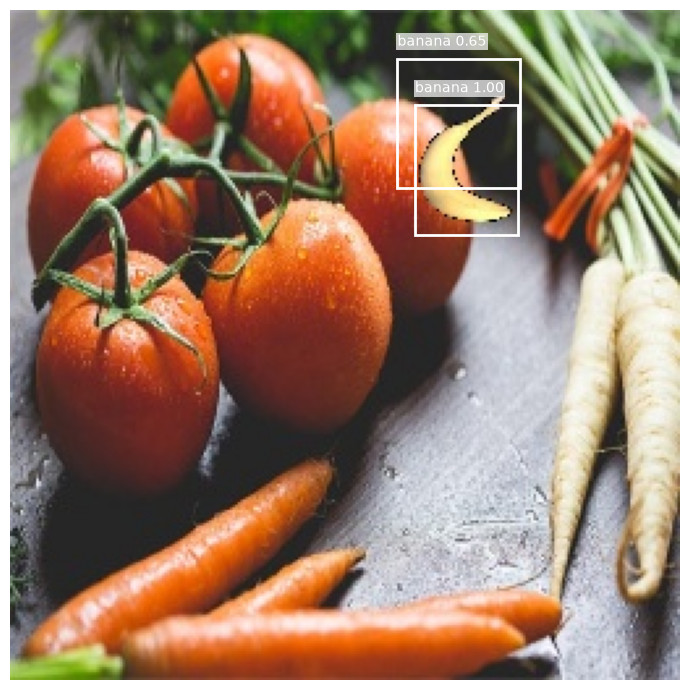

In [16]:
img_path = r"banana.png"
img_tensor = torchvision.io.read_image(img_path).float()

# 模型推理：这里的阈值现在针对真正的 banana 前景概率
boxes, scores, labels = predict_single_image(
    model,
    img_tensor,
    conf_threshold=0.5,
    nms_threshold=0.5
)

# 可选诊断：背景概率高是正常的，关键是不能把背景概率拿来画前景框
model.eval()
with torch.no_grad():
    _, debug_cls_preds, _ = model(
        img_tensor.unsqueeze(0).to(next(model.parameters()).device)
    )
print(inspect_confidence_distribution(debug_cls_preds))

visualize_detections(
    img_tensor,
    boxes,
    scores,
    labels,
    class_names=["banana"],
    conf_threshold=0.5,
    box_color="w",
    figsize=(7, 7)
)
